## Clean & Combine — Regional Weather

Same pipeline as `cleanCombine.ipynb` but uses `weather_hourly_regional.csv` (per-station columns) and outputs `combined_hourly_regional.csv`.

| File | Columns |
|---|---|
| `caiso_hourly.csv` | `load_mw` |
| `weather_hourly_regional.csv` | `{station}_{variable}` × 20 |
| `economic_hourly.csv` | `gas_price_mmbtu`, `is_holiday`, `is_weekend`, `hour_of_day`, `day_of_week`, `month` |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RAW = '../../data/raw'
OUT = '../../data/processed/combined_hourly_regional.csv'
os.makedirs(os.path.dirname(OUT), exist_ok=True)

STATIONS   = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']

# All 20 per-station weather columns
WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]

# Columns to apply outlier detection on (skip binary/calendar and zero-inflated precipitation)
CONTINUOUS = ['load_mw', 'gas_price_mmbtu'] + WEATHER_COLS

### 1. Load & align datetimes

In [2]:
def load(path, dt_col='datetime'):
    df = pd.read_csv(path)
    raw = df[dt_col].astype(str)
    if raw.str.contains(r'[+-]\d{2}:\d{2}$', regex=True).any():
        dt = pd.to_datetime(raw, utc=True).dt.tz_convert('America/Los_Angeles').dt.tz_localize(None)
    else:
        dt = pd.to_datetime(raw)
    df[dt_col] = dt
    return df.set_index(dt_col).sort_index()

caiso   = load(f'{RAW}/caiso_hourly.csv')
weather = load(f'{RAW}/weather_hourly_regional.csv')
econ    = load(f'{RAW}/economic_hourly.csv')

for name, d in [('caiso', caiso), ('weather', weather), ('econ', econ)]:
    print(f'{name:<8} {d.shape}  {d.index[0]}  →  {d.index[-1]}')

caiso    (52607, 1)  2019-01-01 00:00:00  →  2024-12-31 23:00:00
weather  (52608, 20)  2019-01-01 00:00:00  →  2024-12-31 23:00:00
econ     (52608, 6)  2019-01-01 00:00:00  →  2024-12-31 23:00:00


### 2. Merge

In [3]:
df = caiso.join(weather, how='inner').join(econ, how='inner')
print(f'Combined: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Range:    {df.index[0]}  →  {df.index[-1]}')
df.head(3)

Combined: 52,619 rows × 27 columns
Range:    2019-01-01 00:00:00  →  2024-12-31 23:00:00


,load_mw,sacramento_temperature_c,sacramento_precipitation_mm,sacramento_solar_radiation_wm2,sacramento_windspeed_ms,sacramento_humidity_pct,sanjose_temperature_c,sanjose_precipitation_mm,sanjose_solar_radiation_wm2,sanjose_windspeed_ms,...,la_precipitation_mm,la_solar_radiation_wm2,la_windspeed_ms,la_humidity_pct,gas_price_mmbtu,is_holiday,is_weekend,hour_of_day,day_of_week,month
datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,21934,5.4,0.0,0.0,5.56,38,4.4,0.0,0.0,3.76,...,0.0,0.0,2.60,33,NaN,0,0,0,1,1
2019-01-01 01:00:00,21188,5.3,0.0,0.0,5.81,39,3.5,0.0,0.0,3.34,...,0.0,0.0,2.71,30,NaN,0,0,1,1,1
2019-01-01 02:00:00,20613,4.8,0.0,0.0,5.70,40,2.3,0.0,0.0,2.77,...,0.0,0.0,2.70,30,NaN,0,0,2,1,1


### 3. Missing values

In [4]:
missing = df.isnull().mean() * 100
print('Missing % per column:')
print(missing[missing > 0].round(2).to_string() if missing.any() else '  None')

Missing % per column:
gas_price_mmbtu    4.06


### 4. Outlier detection (IQR) → replace with NaN

In [5]:
def flag_outliers(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return pd.Series(False, index=series.index)
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

for col in CONTINUOUS:
    mask = flag_outliers(df[col])
    n = int(mask.sum())
    df.loc[mask, col] = np.nan
    if n > 0:
        print(f'  {col:<35} {n:>5} outliers  ({n/len(df)*100:.2f}%)')

  load_mw                              3000 outliers  (5.70%)
  gas_price_mmbtu                      5160 outliers  (9.81%)
  sacramento_temperature_c              231 outliers  (0.44%)
  sacramento_solar_radiation_wm2          7 outliers  (0.01%)
  sacramento_windspeed_ms              1477 outliers  (2.81%)
  sanjose_temperature_c                 785 outliers  (1.49%)
  sanjose_windspeed_ms                  545 outliers  (1.04%)
  fresno_windspeed_ms                  1281 outliers  (2.43%)
  la_temperature_c                      522 outliers  (0.99%)
  la_windspeed_ms                      1156 outliers  (2.20%)


### 5. Interpolate & fill

In [6]:
df[CONTINUOUS] = df[CONTINUOUS].interpolate(method='time', limit=6)
df[CONTINUOUS] = df[CONTINUOUS].ffill()

for col in CONTINUOUS:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

remaining = df.isnull().sum()
print('NaN remaining after fill:')
print(remaining[remaining > 0].to_string() if remaining.any() else '  None — dataset is complete')

NaN remaining after fill:
  None — dataset is complete


### 6. EDA — regional temperature spread vs load

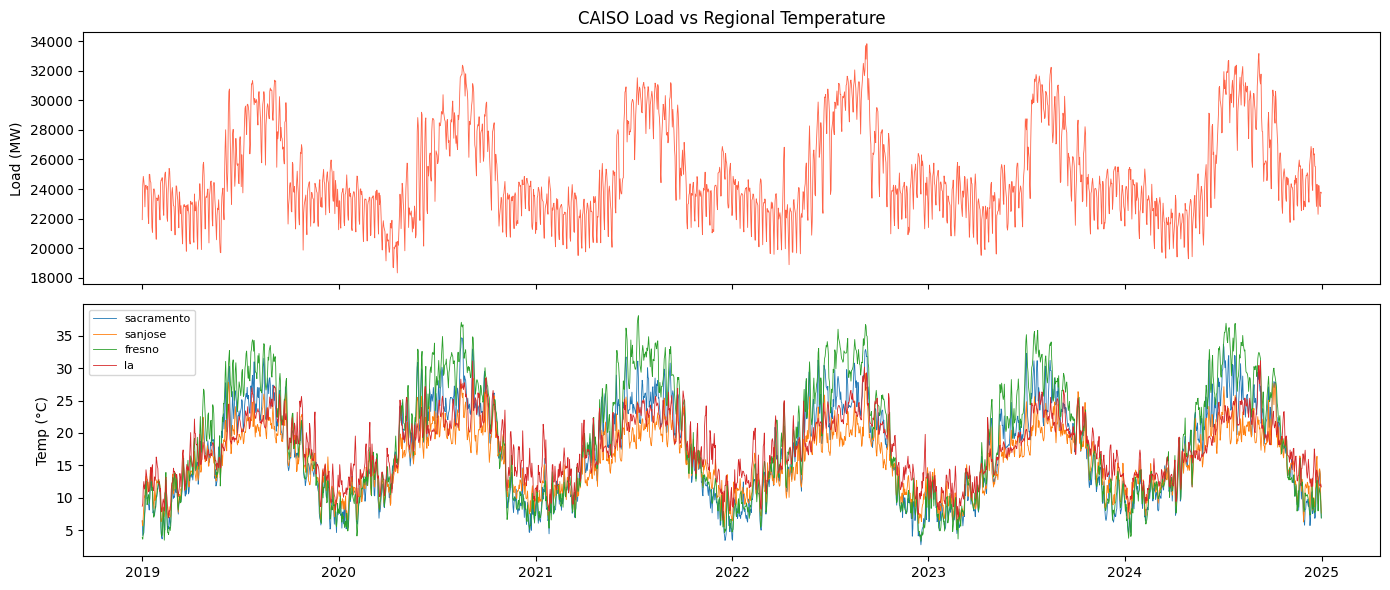

In [7]:
temp_cols = [f'{s}_temperature_c' for s in STATIONS]
daily = df[['load_mw'] + temp_cols].resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(daily.index, daily['load_mw'], linewidth=0.6, color='tomato')
axes[0].set_ylabel('Load (MW)')
axes[0].set_title('CAISO Load vs Regional Temperature')

for col in temp_cols:
    axes[1].plot(daily.index, daily[col], linewidth=0.6, label=col.replace('_temperature_c', ''))
axes[1].set_ylabel('Temp (°C)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 7. Save

In [8]:
df.to_csv(OUT)
print(f'Saved {len(df):,} rows × {len(df.columns)} columns → {OUT}')
print('Columns:', df.columns.tolist())

Saved 52,619 rows × 27 columns → ../../data/processed/combined_hourly_regional.csv
Columns: ['load_mw', 'sacramento_temperature_c', 'sacramento_precipitation_mm', 'sacramento_solar_radiation_wm2', 'sacramento_windspeed_ms', 'sacramento_humidity_pct', 'sanjose_temperature_c', 'sanjose_precipitation_mm', 'sanjose_solar_radiation_wm2', 'sanjose_windspeed_ms', 'sanjose_humidity_pct', 'fresno_temperature_c', 'fresno_precipitation_mm', 'fresno_solar_radiation_wm2', 'fresno_windspeed_ms', 'fresno_humidity_pct', 'la_temperature_c', 'la_precipitation_mm', 'la_solar_radiation_wm2', 'la_windspeed_ms', 'la_humidity_pct', 'gas_price_mmbtu', 'is_holiday', 'is_weekend', 'hour_of_day', 'day_of_week', 'month']
